# YOLOv8 Fine-Tuning on DoclayLaynet
Document layout analysis plays a crucial role in understanding the structure of complex documents by identifying elements such as titles, paragraphs, tables, figures, and lists. The DocLayNet dataset provides a large collection of real-world document images annotated for layout detection tasks, making it a valuable resource for training and evaluating deep learning models.

In this notebook, we focus on fine-tuning the YOLOv8 object detection model on a curated subset of the DocLayNet dataset, which has been uploaded to the Hugging Face Hub. Our goal is to train a lightweight yet powerful model capable of accurately detecting layout components in historical or scanned documents.
- We’ll walk through:
- Setting up the dataset and configuration
- Preparing the YOLOv8 environment
- Training and validation
- Evaluating performance and visualizing results
This fine-tuned model can be further used for downstream tasks like intelligent document processing, OCR post-processing, and structured data extraction.

### Install Required libaries

In [ ]:
!pip install datasets
from datasets import load_dataset
!pip install ultralytics
import numpy as np
import os
import cv2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system ==

### checking for GPU(was originally ran on collab)

In [ ]:
!nvidia-smi

Tue Apr  8 17:05:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Dataset Details
- Name: DocLayNet Subset
- Source: Uploaded to Hugging Face Hub
- Format: COCO-style JSON annotations
- Classes: ['text', 'title', 'list', 'table', 'figure', 'footer', 'header', ...]

In [ ]:
ds = load_dataset("Epicguest97/DocLayNet3")
import os
import cv2

def convert_to_yolo_format(bbox, img_width, img_height):
    x, y, w, h = bbox
    x_center = (x + w / 2) / img_width
    y_center = (y + h / 2) / img_height
    w_norm = w / img_width
    h_norm = h / img_height
    return x_center, y_center, w_norm, h_norm

def save_yolo_labels(data_split, output_dir):
    os.makedirs(f"{output_dir}/images/{data_split}", exist_ok=True)
    os.makedirs(f"{output_dir}/labels/{data_split}", exist_ok=True)

    for i, sample in enumerate(ds[data_split]):
        img = sample['image']
        bboxes = sample['bboxes']
        category_ids = sample['category_id']

        # Convert to NumPy array if necessary
        if not isinstance(img, np.ndarray):
            img = np.array(img)

        img_path = f"{output_dir}/images/{data_split}/{i}.jpg"
        label_path = f"{output_dir}/labels/{data_split}/{i}.txt"
        cv2.imwrite(img_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        with open(label_path, 'w') as f:
            for bbox, category_id in zip(bboxes, category_ids):
                x_center, y_center, w_norm, h_norm = convert_to_yolo_format(bbox, img.shape[1], img.shape[0])
                f.write(f"{category_id} {x_center} {y_center} {w_norm} {h_norm}\n")

save_yolo_labels('train', 'dataset')
save_yolo_labels('val', 'dataset')
save_yolo_labels('test', 'dataset')

README.md:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/271M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.6M [00:00<?, ?B/s]

val-00000-of-00001.parquet:   0%|          | 0.00/24.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/693 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/64 [00:00<?, ? examples/s]

### Dataset Visualisation

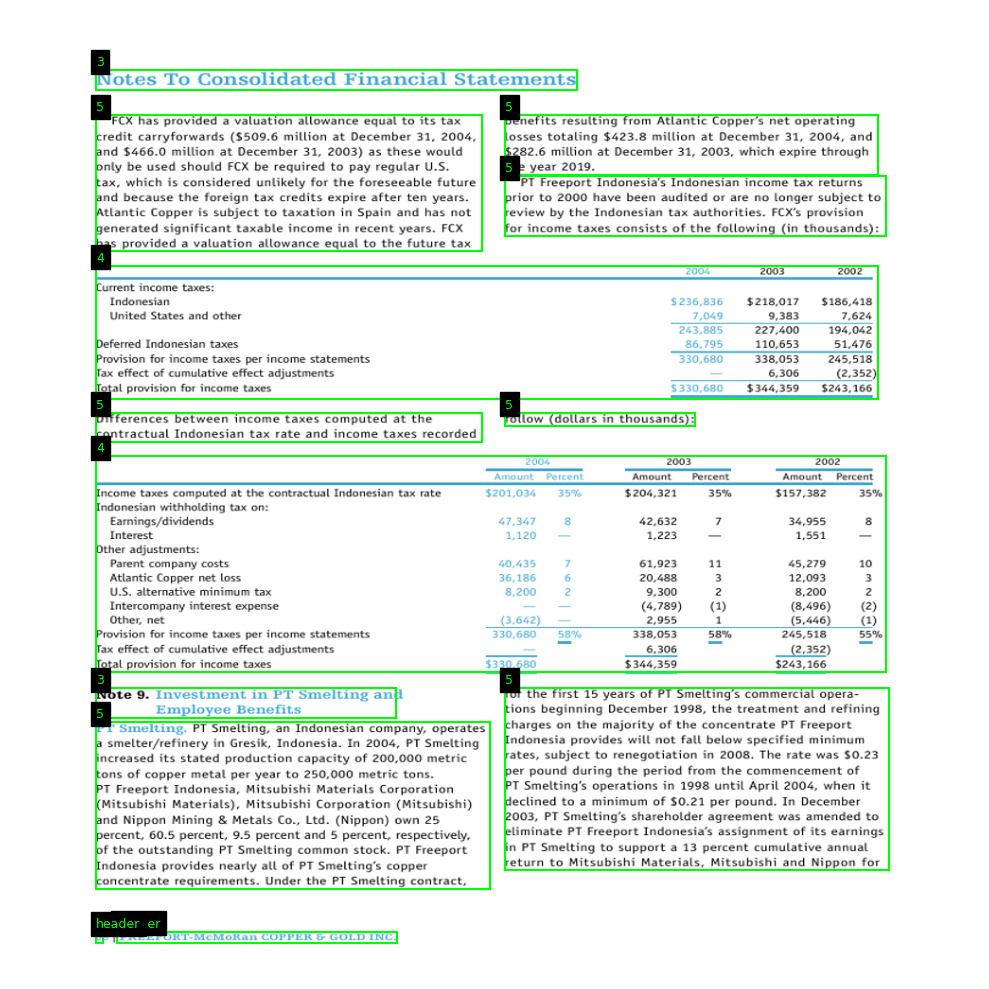

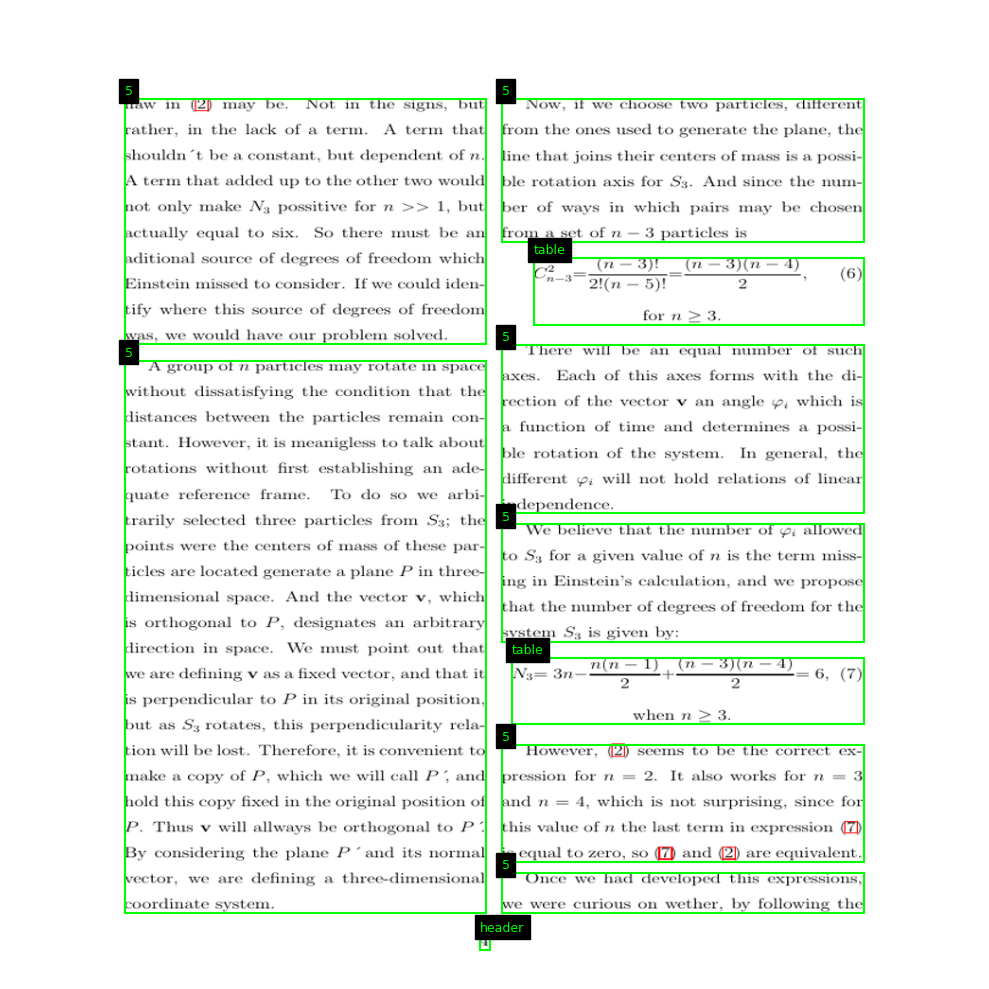

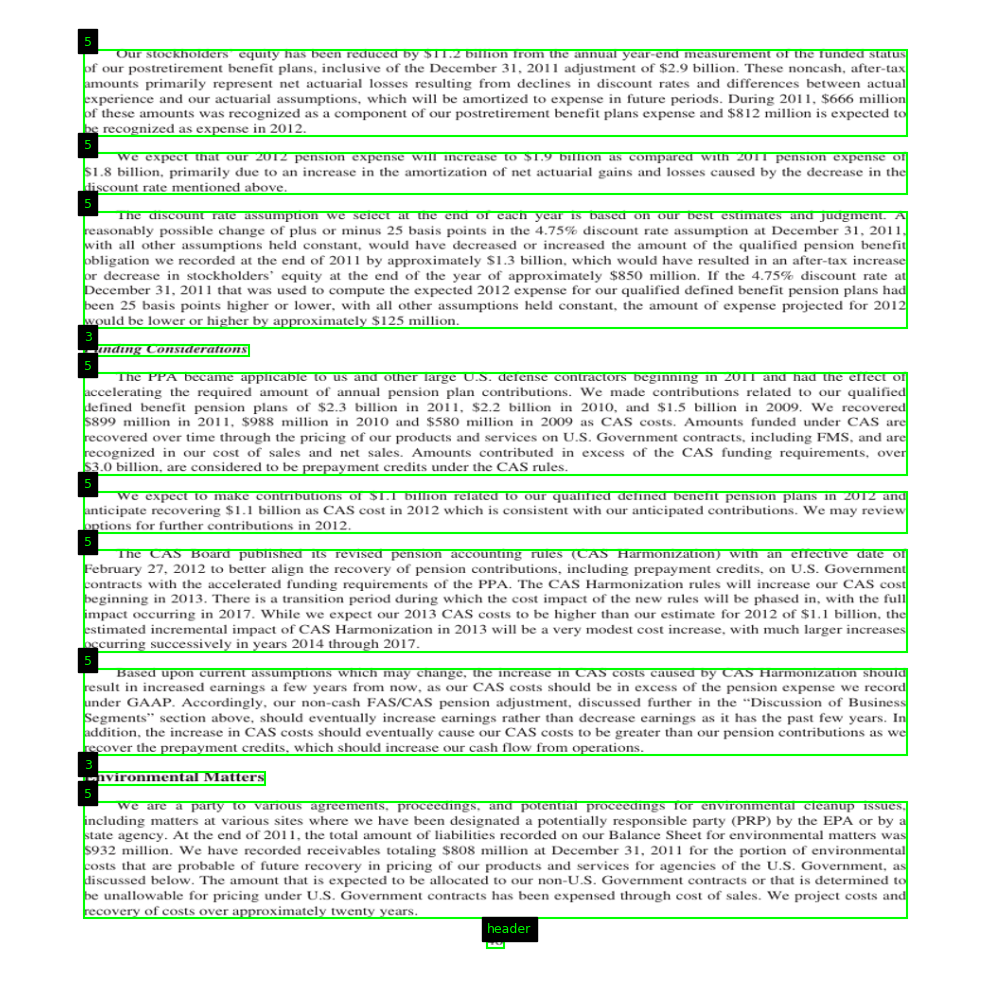

In [ ]:
def plot_sample_with_labels(example, class_names):
    img = example['image']
    bboxes = example['bboxes']
    labels = example['category_id']  # or whatever your label field is called

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img)

    for bbox, label in zip(bboxes, labels):
        x, y, w, h = bbox
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, class_names[label], color='lime', fontsize=9, backgroundcolor='black')

    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage:
class_names = ['text', 'title', 'list', 'table', 'figure', 'header','1','2','3','4','5']
for i in range(10, 13):
    plot_sample_with_labels(ds['train'][i], class_names)


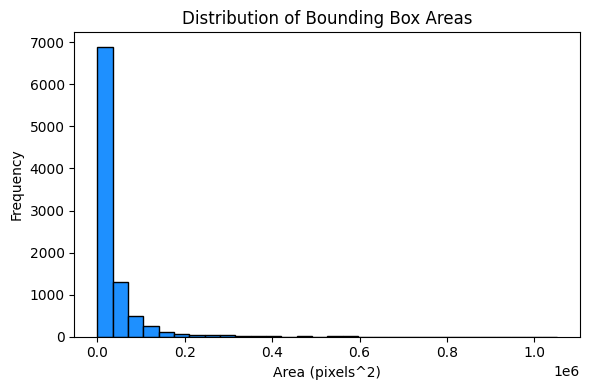

In [ ]:
import numpy as np

box_sizes = []

for ex in ds['train']:
    for box in ex['bboxes']:
        _, _, w, h = box
        box_sizes.append(w * h)

plt.figure(figsize=(6,4))
plt.hist(box_sizes, bins=30, color='dodgerblue', edgecolor='black')
plt.title("Distribution of Bounding Box Areas")
plt.xlabel("Area (pixels^2)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Running the YOLO on Costum Dataset

In [ ]:
!yolo task=detect mode=train data=dataset/data.yaml model=yolov8s.pt epochs=50 imgsz=640 batch=48 save=True


Ultralytics 8.3.98 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=dataset/data.yaml, epochs=50, time=None, patience=100, batch=48, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, l